# Experimento 1

In [1]:
import sys, os, duckdb
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

VARS_DESCARTADAS = (
    'CLOUD_BT', 'CLOUD_BT_MAX', 'CLOUD_BT_MIN',
    'CLOUD_TT', 'CLOUD_TT_MAX', 'CLOUD_TT_MIN',
    'GWM_HEIGHT', 'GWM_HEIGHT_ANOMALY',
    'IMERG_PRECLIQUID_PROB', 'IMERG_PRECTOT', 'IMERG_PRECTOT_COUNT',
    'LWLAND', 'ORIGINAL_ALLSKY_SFC_LW_DWN', 'ORIGINAL_ALLSKY_SFC_SW_DWN',
    'ORIGINAL_CLRSKY_SFC_LW_DWN', 'ORIGINAL_CLRSKY_SFC_SW_DWN',
    'PRMC', 'PRMC_PRCNTL', 'RZMC', 'RZMC_PRCNTL',
    'SFMC', 'SWLAND', 'SZA'
)
vars_excluidas_sql = ", ".join([f"'{v}'" for v in VARS_DESCARTADAS])

vars_clima = con.execute(f"""
    SELECT DISTINCT id_variable
    FROM working.climatologia
    WHERE id_variable NOT IN ({vars_excluidas_sql})
    ORDER BY id_variable
""").df()['id_variable'].tolist()

pivot_cols = ",\n    ".join([
    f"AVG(CASE WHEN id_variable = '{v}' THEN resultado_numerico END) AS \"{v}\""
    for v in vars_clima
])

df = con.execute(f"""
    WITH clima_pivot AS (
        SELECT
            id_clave_inc,
            {pivot_cols}
        FROM working.climatologia
        WHERE id_variable NOT IN ({vars_excluidas_sql})
        GROUP BY id_clave_inc
    ),
    demo_total AS (
        SELECT
            id_cvegeo,
            anio,
            SUM(pob_total) AS pob_total
        FROM working.demografia
        GROUP BY id_cvegeo, anio
    )
    SELECT
        i.id_clave_inc,
        i.latitud,
        i.longitud,
        i.anio,
        EXTRACT(MONTH FROM i.fecha_inicio)::INTEGER AS mes,
        EXTRACT(DOW   FROM i.fecha_inicio)::INTEGER AS dia_semana,
        i.tipo_de_incendio,
        v.tipo_de_vegetacion,
        v.regimen_del_fuego,
        m.nombre_municipio,
        o.hora_deteccion,
        dem.pob_total,
        d.tamanio,
        cp.*
    FROM working.incendios i
    LEFT JOIN working.vegetacion   v   ON i.id_vegetacion = v.id_vegetacion
    LEFT JOIN working.municipios   m   ON i.id_cvegeo     = m.id_cvegeo
    LEFT JOIN working.operaciones  o   ON i.id_clave_inc  = o.id_clave_inc
    LEFT JOIN working.danos        d   ON i.id_clave_inc  = d.id_clave_inc
    LEFT JOIN demo_total           dem ON i.id_cvegeo     = dem.id_cvegeo
                                      AND i.anio          = dem.anio
    LEFT JOIN clima_pivot          cp  ON i.id_clave_inc  = cp.id_clave_inc
""").df()

con.close()

df = df.loc[:, ~df.columns.duplicated()]

# Convertir hora_deteccion a minutos desde medianoche
df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')
df['hora_deteccion_min'] = (
    df['hora_deteccion'].dt.hour * 60 +
    df['hora_deteccion'].dt.minute
)
df = df.drop(columns=['hora_deteccion'])

print("Pivoteo listo.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pivoteo listo.


/tmp/ipykernel_6230/2456706728.py:82: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')


In [2]:
pd.set_option('display.max_columns', None)
print(df.head())


  id_clave_inc    latitud    longitud  anio  mes  dia_semana tipo_de_incendio  \
0   19-15-0047  19.560278  -99.168335  2019    2           5      superficial   
1   19-15-0048  19.242695 -100.133057  2019    2           6      superficial   
2   19-15-0058  19.246778 -100.112808  2019    2           0      superficial   
3   19-15-0054  19.170666 -100.235031  2019    2           0      superficial   
4   19-15-0057  18.933056  -99.744446  2019    2           0      superficial   

      tipo_de_vegetacion regimen_del_fuego     nombre_municipio  pob_total  \
0    matorral crasicaule             otros  tlalnepantla de baz   687329.0   
1  bosque de pino-encino          adaptado       valle de bravo    63170.0   
2  bosque de pino-encino          adaptado       valle de bravo    63170.0   
3  bosque de pino-encino          adaptado          santo tomas     9885.0   
4  bosque de pino-encino          adaptado     coatepec harinas    39458.0   

           tamanio id_clave_inc_1  AIRMASS  

In [3]:
# Eliminar columna duplicada
df = df.drop(columns=['id_clave_inc_1'], errors='ignore')

# Mapear target
mapa_tamanio = {
    '0 a 5 hectareas'       : '1_0_a_5',
    '6 a 10 hectareas'      : '2_6_a_20',
    '11 a 20 hectareas'     : '2_6_a_20',
    '21 a 50 hectareas'     : '3_21_a_50',
    '51 a 100 hectareas'    : '4_mas_de_50',
    'mayor a 100 hectareas' : '4_mas_de_50',
}
df['tamanio_modelo'] = df['tamanio'].map(mapa_tamanio)
df = df.drop(columns=['tamanio'])

print("Pivoteo listo.")

Pivoteo listo.


In [4]:
# ================================================================
# INSPECCIÓN — nulos y duplicados
# ================================================================
# Duplicados
print(f"Filas duplicadas : {df.duplicated().sum()}")
print(f"IDs duplicados   : {df['id_clave_inc'].duplicated().sum()}")

# Nulos por columna
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(f"\nColumnas con nulos ({len(nulos)} de {df.shape[1]}):")
print(nulos.to_string())

# Nulos por fila
nulos_por_fila = df.isnull().sum(axis=1)
print(f"\nFilas con al menos 1 nulo : {(nulos_por_fila > 0).sum()}")
print(f"Filas con más de 5 nulos  : {(nulos_por_fila > 5).sum()}")
print(f"Filas con más de 10 nulos : {(nulos_por_fila > 10).sum()}")

print("\nInspección lista.")

Filas duplicadas : 0
IDs duplicados   : 0

Columnas con nulos (19 de 135):
latitud               174
longitud              174
EVLAND                105
TSOIL5                105
EVPTRNS               105
FRSNO                 105
GWETPROF              105
GWETROOT              105
PRECSNOLAND           105
SNODP                 105
TSOIL1                105
TSURF                 105
TSOIL2                105
TSOIL3                105
TSOIL4                105
TSOIL6                105
CLRSKY_NKT             33
hora_deteccion_min      3
NDMI                    2

Filas con al menos 1 nulo : 212
Filas con más de 5 nulos  : 105
Filas con más de 10 nulos : 105

Inspección lista.


In [5]:
mask_suelo  = df['TSOIL1'].isnull()
mask_coords = df['latitud'].isnull()

print(f"Filas con nulos de suelo Y sin coordenadas: {(mask_suelo & mask_coords).sum()}")

print("\nAños — nulos de suelo:")
print(df[mask_suelo]['anio'].value_counts().sort_index())

print("\nAños — sin coordenadas:")
print(df[mask_coords]['anio'].value_counts().sort_index())

print("\nTarget — nulos de suelo:")
print(df[mask_suelo]['tamanio_modelo'].value_counts())

print("\nTarget — sin coordenadas:")
print(df[mask_coords]['tamanio_modelo'].value_counts())

print("\nDiagnóstico listo.")

Filas con nulos de suelo Y sin coordenadas: 105

Años — nulos de suelo:
anio
2015    36
2016    69
Name: count, dtype: int64

Años — sin coordenadas:
anio
2015    38
2016    80
2017     8
2018    10
2019     1
2020    11
2021     3
2022     7
2023     7
2024     7
2025     2
Name: count, dtype: int64

Target — nulos de suelo:
tamanio_modelo
1_0_a_5        88
2_6_a_20       13
4_mas_de_50     3
3_21_a_50       1
Name: count, dtype: int64

Target — sin coordenadas:
tamanio_modelo
1_0_a_5        110
2_6_a_20        35
4_mas_de_50     21
3_21_a_50        8
Name: count, dtype: int64

Diagnóstico listo.


In [6]:
total        = len(df)
a_eliminar   = df['latitud'].isnull().sum()
quedan       = total - a_eliminar
print(f"Total          : {total}")
print(f"A eliminar     : {a_eliminar}")
print(f"Quedan         : {quedan}  ({quedan/total*100:.1f}%)")

Total          : 12703
A eliminar     : 174
Quedan         : 12529  (98.6%)


In [7]:
# ================================================================
# LIMPIEZA — eliminación de filas con nulos críticos
# ================================================================

# Eliminar filas sin coordenadas (incluye las 105 de suelo)
df = df[df['latitud'].notnull()].copy()

# Imputar nulos menores con mediana
for col in ['CLRSKY_NKT', 'hora_deteccion_min', 'NDMI']:
    df[col] = df[col].fillna(df[col].median())

# Verificación
nulos_restantes = df.isnull().sum().sum()
print(f"Shape final     : {df.shape}")
print(f"Nulos restantes : {nulos_restantes}")

print("\nLimpieza lista.")

Shape final     : (12529, 135)
Nulos restantes : 0

Limpieza lista.


In [8]:

cols_categoricas = ['tipo_de_incendio', 'tipo_de_vegetacion', 
                    'regimen_del_fuego', 'nombre_municipio']

for col in cols_categoricas:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.replace('\n', ' ')
    df[col] = df[col].str.replace('\t', ' ')
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

# Unificar categorías equivalentes
df['tipo_de_vegetacion'] = df['tipo_de_vegetacion'].str.replace(
    'bosque de encino-pino', 'bosque de pino-encino'
)

# Verificación
print(df['tipo_de_vegetacion'].value_counts().to_string())
print("\nLimpieza de categóricas lista.")

tipo_de_vegetacion
bosque de pino                                              4669
bosque de pino-encino                                       4040
bosque de encino                                            2141
bosque de oyamel                                             927
matorral crasicaule                                          299
bosque mesofilo de montana                                   165
bosque cultivado                                              79
bosque de tascate                                             62
bosque de cedro                                               57
selva baja caducifolia                                        51
pradera de alta montana                                       18
bosque inducido                                                6
pastizal natural                                               4
pastizal halofilo                                              3
matorral submontano                                            2
tular 

In [9]:
cols_categoricas = ['tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio']

for col in cols_categoricas:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


tipo_de_incendio:
tipo_de_incendio
superficial    12435
mixto             74
de copa           18
subterraneo        2

tipo_de_vegetacion:
tipo_de_vegetacion
bosque de pino                                              4669
bosque de pino-encino                                       4040
bosque de encino                                            2141
bosque de oyamel                                             927
matorral crasicaule                                          299
bosque mesofilo de montana                                   165
bosque cultivado                                              79
bosque de tascate                                             62
bosque de cedro                                               57
selva baja caducifolia                                        51
pradera de alta montana                                       18
bosque inducido                                                6
pastizal natural                                            

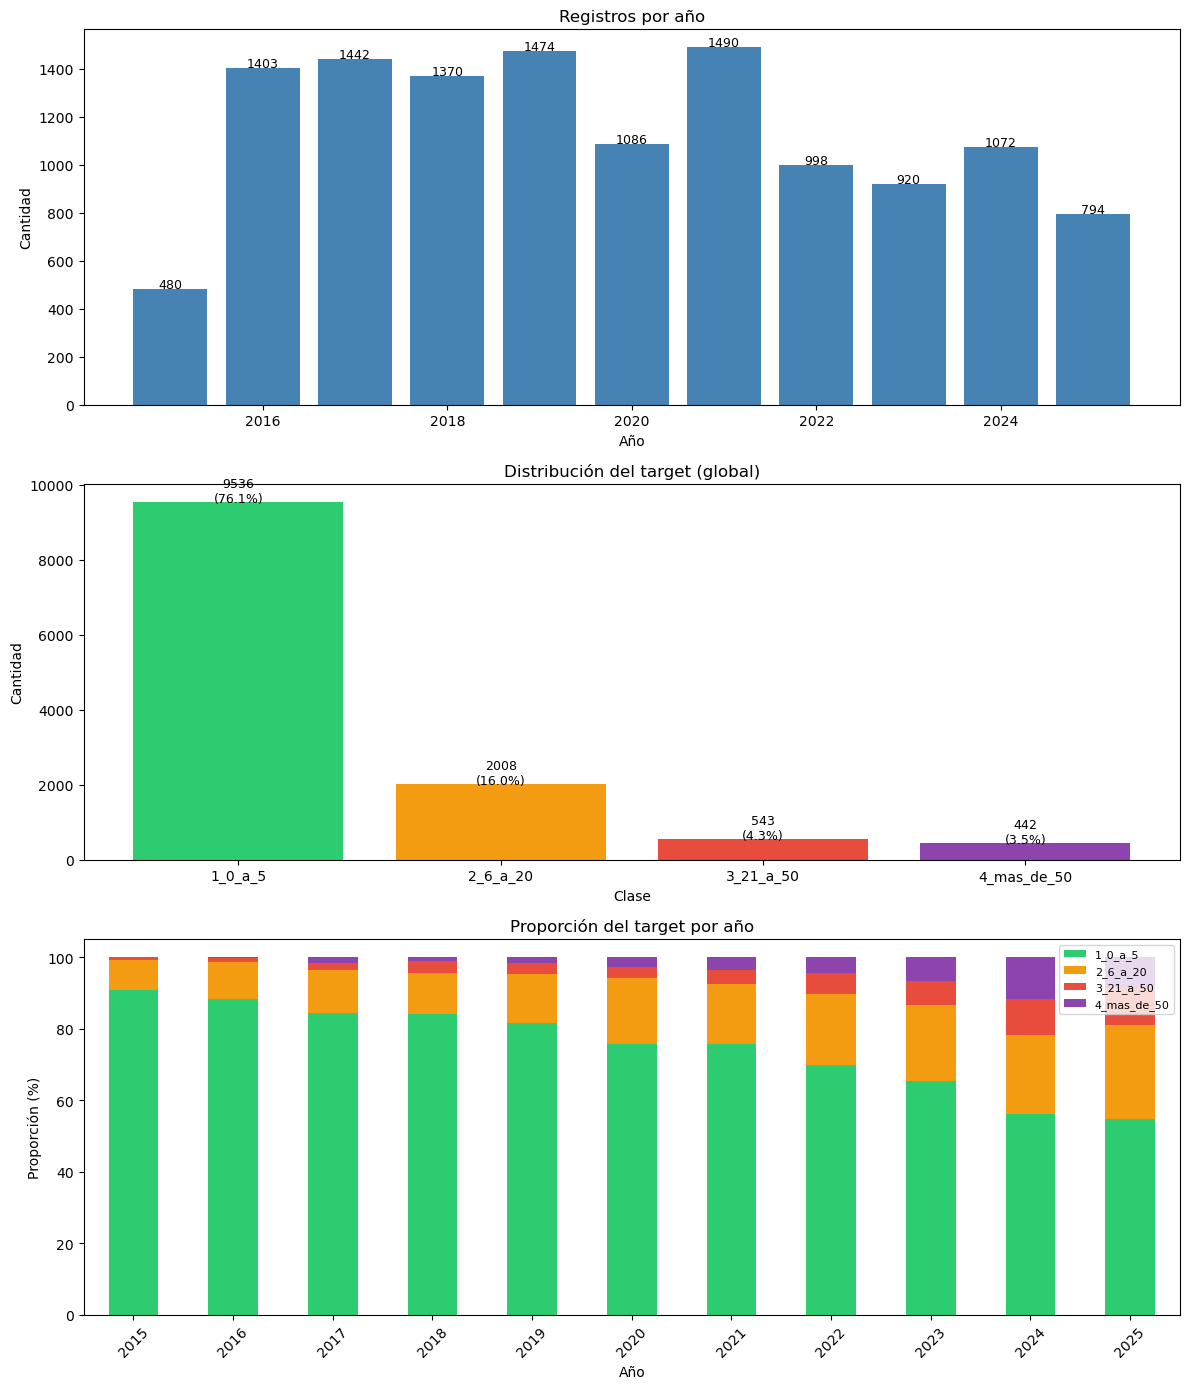

Gráfica guardada.


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# --- Gráfica 1: Registros por año ---
conteo_anio = df.groupby('anio').size()
axes[0].bar(conteo_anio.index, conteo_anio.values, color='steelblue')
axes[0].set_title('Registros por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')
for i, (anio, val) in enumerate(conteo_anio.items()):
    axes[0].text(anio, val + 5, str(val), ha='center', fontsize=9)

# --- Gráfica 2: Distribución del target global ---
dist = df['tamanio_modelo'].value_counts().sort_index()
colores = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
axes[1].bar(dist.index, dist.values, color=colores)
axes[1].set_title('Distribución del target (global)')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Cantidad')
for i, (clase, val) in enumerate(dist.items()):
    axes[1].text(i, val + 10, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

# --- Gráfica 3: Target por año (proporciones) ---
target_anio = df.groupby(['anio', 'tamanio_modelo']).size().unstack(fill_value=0)
target_anio_pct = target_anio.div(target_anio.sum(axis=1), axis=0) * 100
target_anio_pct.plot(kind='bar', stacked=True, ax=axes[2], color=colores)
axes[2].set_title('Proporción del target por año')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Proporción (%)')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")


Para el split mi recomendación sería:

Train: 2015 — 2022 (~10,000 registros)
Validation: 2023 (~998 registros)
Test: 2024 — 2025 (~1,866 registros)

In [11]:
# ================================================================
# SPLIT TEMPORAL
# ================================================================

train = df[df['anio'] <= 2022].copy()
val   = df[df['anio'] == 2023].copy()
test  = df[df['anio'] >= 2024].copy()

# Verificación
print(f"Train : {len(train):>5} registros  ({train['anio'].min()}-{train['anio'].max()})")
print(f"Val   : {len(val):>5} registros  ({val['anio'].min()}-{val['anio'].max()})")
print(f"Test  : {len(test):>5} registros  ({test['anio'].min()}-{test['anio'].max()})")

print(f"\nProporción train : {len(train)/len(df)*100:.1f}%")
print(f"Proporción val   : {len(val)/len(df)*100:.1f}%")
print(f"Proporción test  : {len(test)/len(df)*100:.1f}%")

# Distribución del target en cada split
for nombre, split in [('Train', train), ('Val', val), ('Test', test)]:
    print(f"\nTarget — {nombre}:")
    dist = split['tamanio_modelo'].value_counts().sort_index()
    for clase, cnt in dist.items():
        print(f"   {clase:<20} {cnt:>4}  ({cnt/len(split)*100:.1f}%)")

print("\nSplit listo.")

Train :  9743 registros  (2015-2022)
Val   :   920 registros  (2023-2023)
Test  :  1866 registros  (2024-2025)

Proporción train : 77.8%
Proporción val   : 7.3%
Proporción test  : 14.9%

Target — Train:
   1_0_a_5              7897  (81.1%)
   2_6_a_20             1367  (14.0%)
   3_21_a_50             292  (3.0%)
   4_mas_de_50           187  (1.9%)

Target — Val:
   1_0_a_5               602  (65.4%)
   2_6_a_20              196  (21.3%)
   3_21_a_50              61  (6.6%)
   4_mas_de_50            61  (6.6%)

Target — Test:
   1_0_a_5              1037  (55.6%)
   2_6_a_20              445  (23.8%)
   3_21_a_50             190  (10.2%)
   4_mas_de_50           194  (10.4%)

Split listo.


In [12]:
# ================================================================
# SPLIT TEMPORAL
# ================================================================

train = df[df['anio'] <= 2022].copy()
val   = df[df['anio'] == 2023].copy()
test  = df[df['anio'] >= 2024].copy()

# Verificación
print(f"Train : {len(train):>5} registros  ({train['anio'].min()}-{train['anio'].max()})")
print(f"Val   : {len(val):>5} registros  ({val['anio'].min()}-{val['anio'].max()})")
print(f"Test  : {len(test):>5} registros  ({test['anio'].min()}-{test['anio'].max()})")
print("\nSplit listo.")

Train :  9743 registros  (2015-2022)
Val   :   920 registros  (2023-2023)
Test  :  1866 registros  (2024-2025)

Split listo.


Precaución: 3 variables constantes descartadas.
Climáticas procesadas  : 119
Grupos encontrados     : 33
Variables eliminadas   : 86


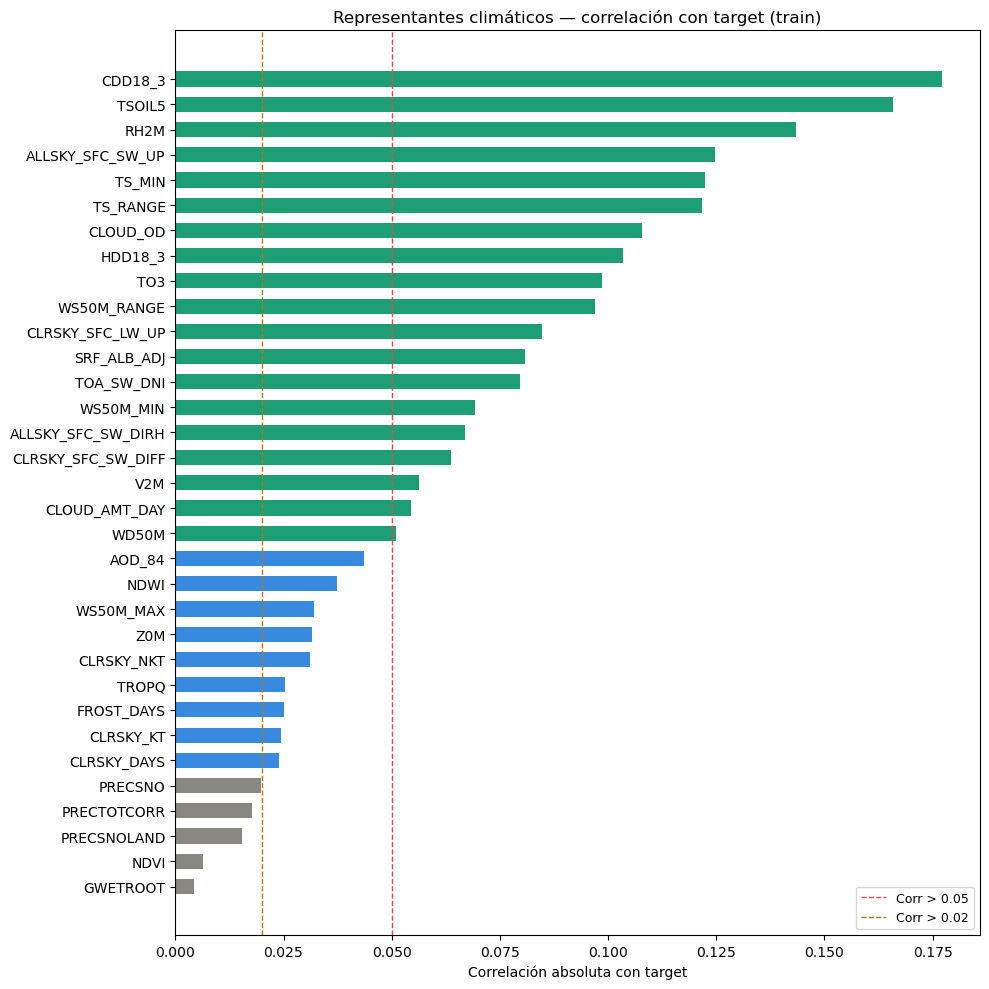


Pearson listo.


In [13]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================================================
# PEARSON — CLUSTERING DE CORRELACIÓN (solo sobre train)
# ================================================================

TARGET_COL   = 'tamanio_modelo'
cols_clima   = [c for c in train.columns if c in vars_clima]

# Encoding ordinal del target
orden_clases = [['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50']]
enc_target   = OrdinalEncoder(categories=orden_clases)
y_ord        = enc_target.fit_transform(train[[TARGET_COL]]).ravel()

# Preparar matriz climática solo del train
df_clima = train[cols_clima].copy()
df_clima = df_clima.dropna(axis=1, how='all')
df_clima = df_clima.fillna(df_clima.median())

desviacion   = df_clima.std()
cols_validas = desviacion[desviacion > 0].index
if len(cols_validas) < len(df_clima.columns):
    eliminadas = len(df_clima.columns) - len(cols_validas)
    print(f"Precaución: {eliminadas} variables constantes descartadas.")
df_clima = df_clima[cols_validas]

# Clustering jerárquico
dist_condensada = pdist(df_clima.values.T, metric='correlation')
dist_condensada = np.nan_to_num(dist_condensada, nan=0.0, posinf=1.0, neginf=-1.0)
dist_condensada = np.clip(dist_condensada, 0, None)

linkage        = hierarchy.ward(dist_condensada)
cluster_labels = hierarchy.fcluster(linkage, t=0.5, criterion='distance')

grupos_df = pd.DataFrame({
    'variable': df_clima.columns,
    'grupo'   : cluster_labels
})

representantes = []
log_grupos     = []

for g in sorted(grupos_df['grupo'].unique()):
    vars_grupo  = grupos_df[grupos_df['grupo'] == g]['variable'].tolist()
    corr_target = {}
    for v in vars_grupo:
        try:
            corr_val = abs(np.corrcoef(df_clima[v], y_ord)[0, 1])
            corr_target[v] = corr_val if not np.isnan(corr_val) else 0.0
        except:
            corr_target[v] = 0.0

    mejor = max(corr_target, key=corr_target.get)
    representantes.append(mejor)
    log_grupos.append({
        'grupo'        : g,
        'n_vars'       : len(vars_grupo),
        'representante': mejor,
        'corr_target'  : round(corr_target[mejor], 4),
        'descartadas'  : ', '.join([v for v in vars_grupo if v != mejor])
    })

df_log = (pd.DataFrame(log_grupos)
            .sort_values('corr_target', ascending=False)
            .reset_index(drop=True))

cols_clima_reducidas = representantes.copy()

print(f"Climáticas procesadas  : {len(df_clima.columns)}")
print(f"Grupos encontrados     : {len(representantes)}")
print(f"Variables eliminadas   : {len(df_clima.columns) - len(representantes)}")

# ================================================================
# GRÁFICA
# ================================================================
colores = [
    '#1D9E75' if v > 0.05 else '#378ADD' if v > 0.02 else '#888780'
    for v in df_log['corr_target']
]
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(df_log['representante'][::-1], df_log['corr_target'][::-1],
        color=colores[::-1], height=0.6)
ax.set_title('Representantes climáticos — correlación con target (train)')
ax.set_xlabel('Correlación absoluta con target')
ax.axvline(x=0.05, color='#E24B4A', linestyle='--', linewidth=1, label='Corr > 0.05')
ax.axvline(x=0.02, color='#BA7517', linestyle='--', linewidth=1, label='Corr > 0.02')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nPearson listo.")

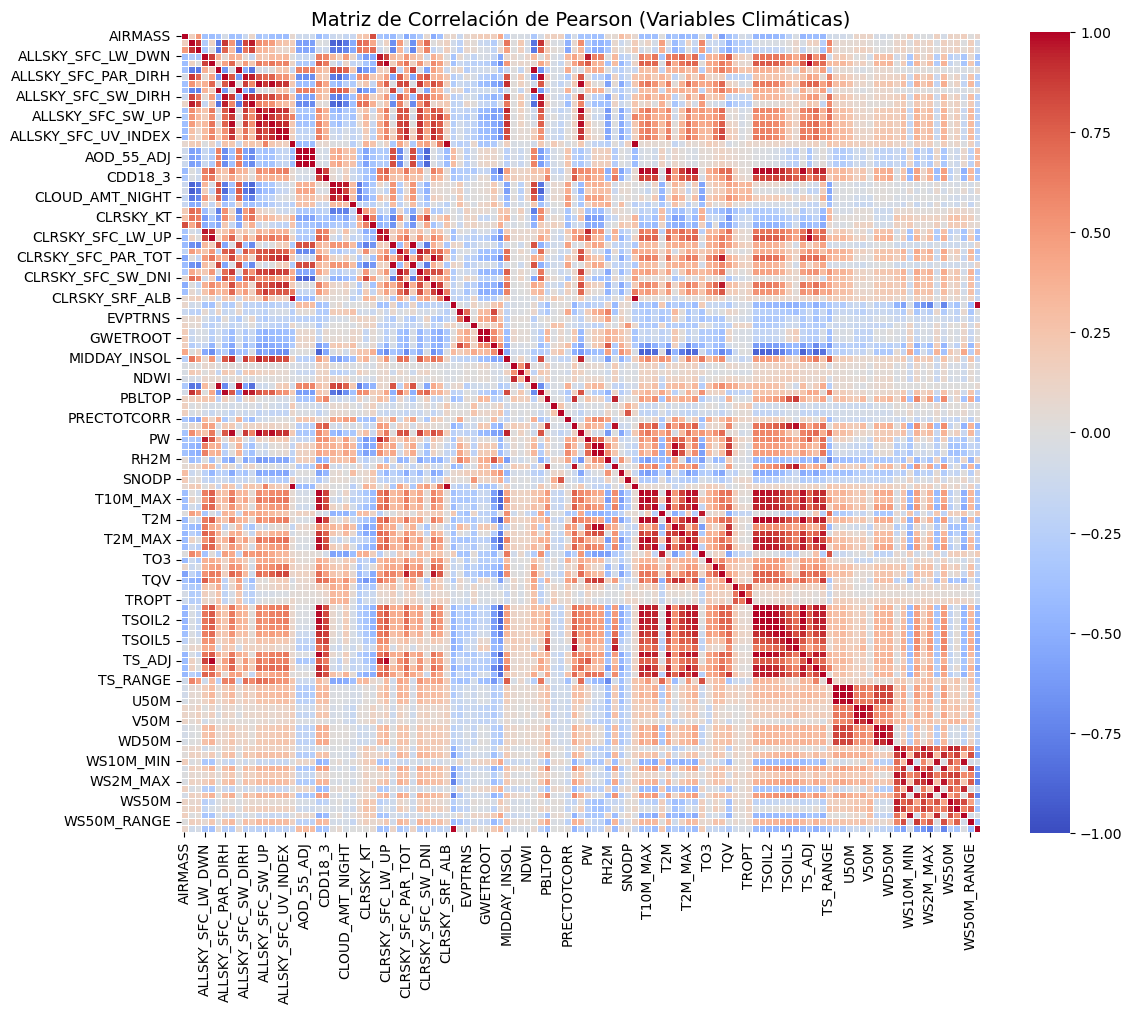

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calculamos la matriz de correlación de las variables climáticas originales
matriz_corr = df_clima.corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))

# Generamos el Heatmap
sns.heatmap(matriz_corr, 
            cmap='coolwarm',  # Colores: Azul (negativa), Blanco (cero), Rojo (positiva)
            vmin=-1, vmax=1,  # Rango de Pearson
            annot=False,      # Apagamos los números porque son muchas variables
            square=True, 
            linewidths=.5)

ax.set_title('Matriz de Correlación de Pearson (Variables Climáticas)', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:

# Quitar representantes con corr < 0.02
cols_clima_finales = df_log[df_log['corr_target'] >= 0.02]['representante'].tolist()

print(f"Climáticas antes : {len(cols_clima_reducidas)}")
print(f"Climáticas finales: {len(cols_clima_finales)}")

# Columnas no climáticas
cols_no_clima = ['latitud', 'longitud', 'mes', 'dia_semana', 'tipo_de_incendio',
                 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio',
                 'pob_total', 'hora_deteccion_min']

ID_COL     = 'id_clave_inc'
TARGET_COL = 'tamanio_modelo'

cols_features = cols_no_clima + cols_clima_finales

# Separar X e y
X_train = train[cols_features].copy()
y_train = train[TARGET_COL]

X_val   = val[cols_features].copy()
y_val   = val[TARGET_COL]

X_test  = test[cols_features].copy()
y_test  = test[TARGET_COL]

print(f"\nX_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print("\nFeatures listas.")

Climáticas antes : 33
Climáticas finales: 28

X_train : (9743, 38)
X_val   : (920, 38)
X_test  : (1866, 38)

Features listas.


In [18]:
from sklearn.preprocessing import OrdinalEncoder

# ================================================================
# ENCODING DE CATEGÓRICAS
# ================================================================

cols_categoricas = ['tipo_de_incendio', 'tipo_de_vegetacion',
                    'regimen_del_fuego', 'nombre_municipio']

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Aprender solo del train
X_train[cols_categoricas] = enc.fit_transform(X_train[cols_categoricas])

# Aplicar a val y test sin reajustar
X_val[cols_categoricas]   = enc.transform(X_val[cols_categoricas])
X_test[cols_categoricas]  = enc.transform(X_test[cols_categoricas])

print("Tipos de datos después del encoding:")
print(X_train.dtypes.value_counts())
print("\nEncoding listo.")

Tipos de datos después del encoding:
float64    34
float32     2
int32       2
Name: count, dtype: int64

Encoding listo.


Modelo entrenado.

--- Validación ---
              precision    recall  f1-score   support

     1_0_a_5       0.68      0.98      0.80       602
    2_6_a_20       0.26      0.04      0.07       196
   3_21_a_50       0.00      0.00      0.00        61
 4_mas_de_50       0.36      0.08      0.13        61

    accuracy                           0.65       920
   macro avg       0.32      0.28      0.25       920
weighted avg       0.52      0.65      0.55       920



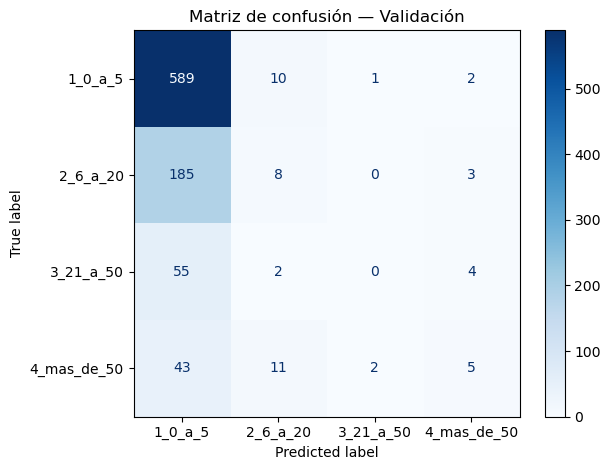

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = None,
    min_samples_leaf= 5,
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1
)

clf.fit(X_train, y_train)
print("Modelo entrenado.")

y_pred_val = clf.predict(X_val)

print("\n--- Validación ---")
print(classification_report(y_val, y_pred_val))

cm  = confusion_matrix(y_val, y_pred_val, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — Validación')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6230/2228745322.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


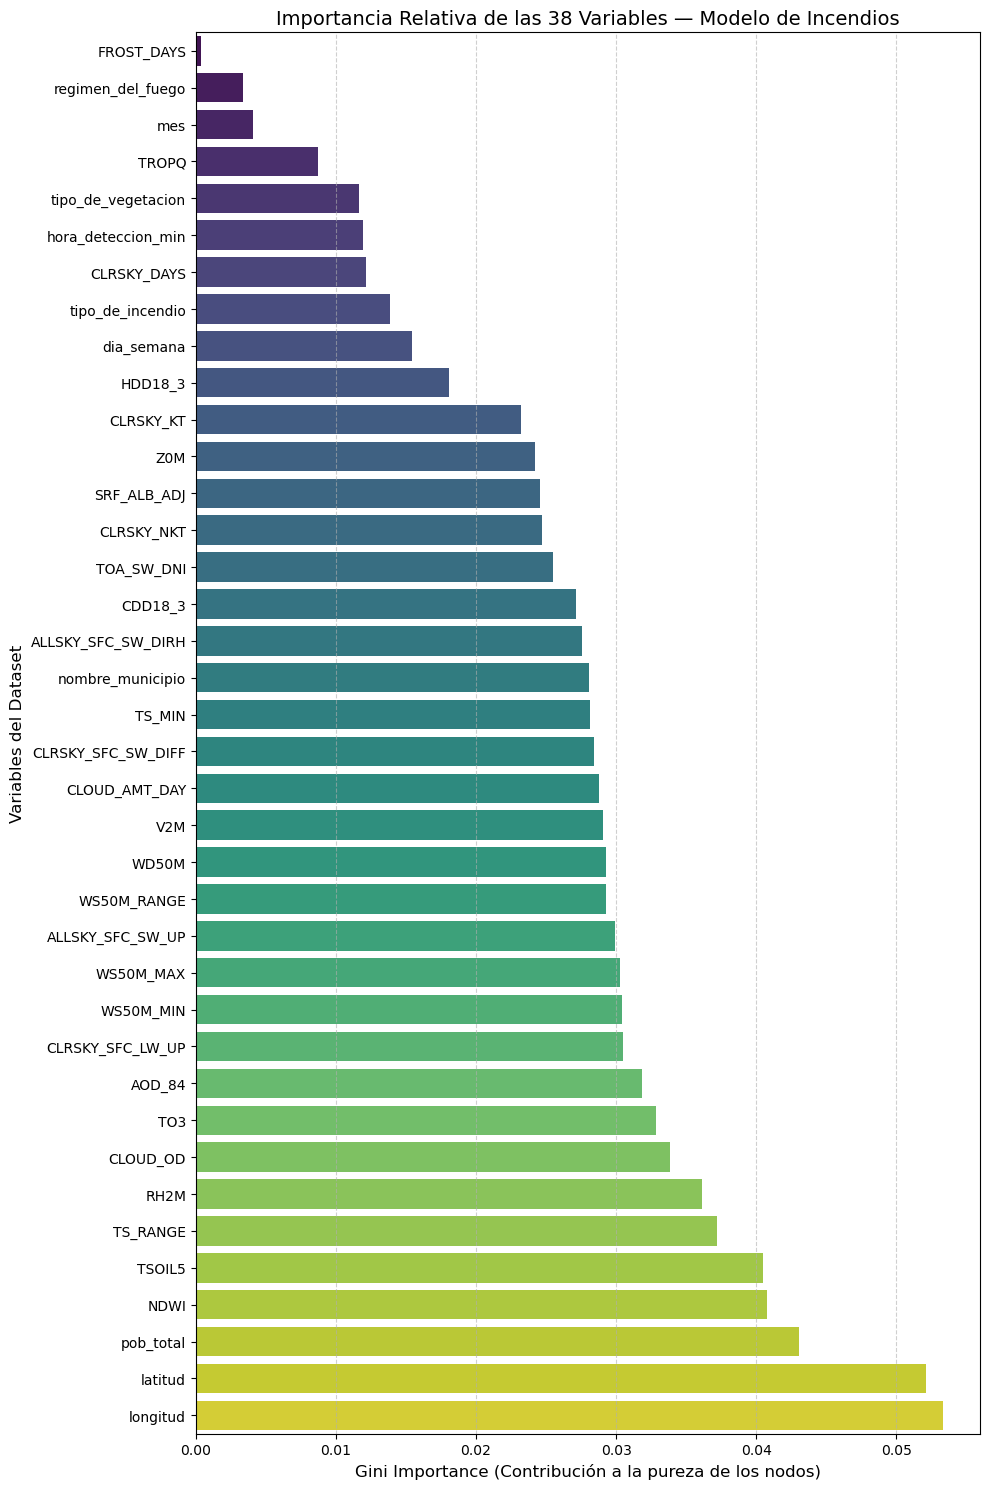


--- Listado Completo de Importancias ---
              Variable  Importancia
1             longitud     0.053305
0              latitud     0.052131
8            pob_total     0.043070
30                NDWI     0.040744
11              TSOIL5     0.040499
15            TS_RANGE     0.037189
12                RH2M     0.036099
16            CLOUD_OD     0.033855
18                 TO3     0.032876
29              AOD_84     0.031845
20    CLRSKY_SFC_LW_UP     0.030484
23           WS50M_MIN     0.030381
31           WS50M_MAX     0.030297
13    ALLSKY_SFC_SW_UP     0.029912
19         WS50M_RANGE     0.029281
28               WD50M     0.029246
26                 V2M     0.029025
27       CLOUD_AMT_DAY     0.028779
25  CLRSKY_SFC_SW_DIFF     0.028408
14              TS_MIN     0.028139
7     nombre_municipio     0.028028
24  ALLSKY_SFC_SW_DIRH     0.027582
10             CDD18_3     0.027136
22          TOA_SW_DNI     0.025510
33          CLRSKY_NKT     0.024672
21         SRF_ALB_ADJ

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = clf.feature_importances_
feature_names = X_train.columns

# 2. Crear un DataFrame ordenado
df_importance = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=True) 

plt.figure(figsize=(10, 15)) 

sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importance, 
    palette='viridis'
)

plt.title('Importancia Relativa de las 38 Variables — Modelo de Incendios', fontsize=14)
plt.xlabel('Gini Importance (Contribución a la pureza de los nodos)', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Mostrar la tabla completa en consola por si necesitas los valores exactos
pd.set_option('display.max_rows', None) 
print("\n--- Listado Completo de Importancias ---")
print(df_importance.sort_values(by='Importancia', ascending=False))

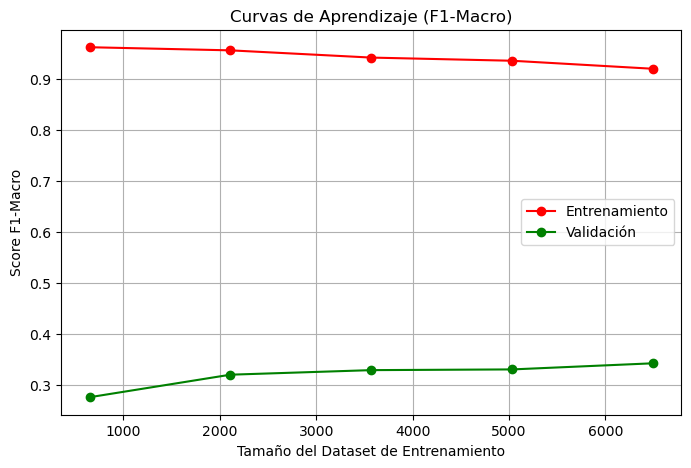

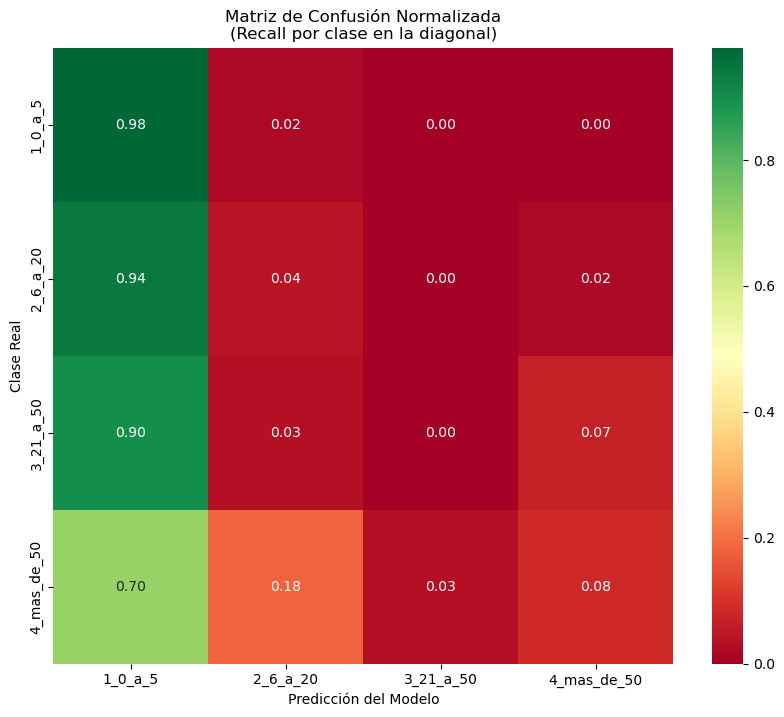

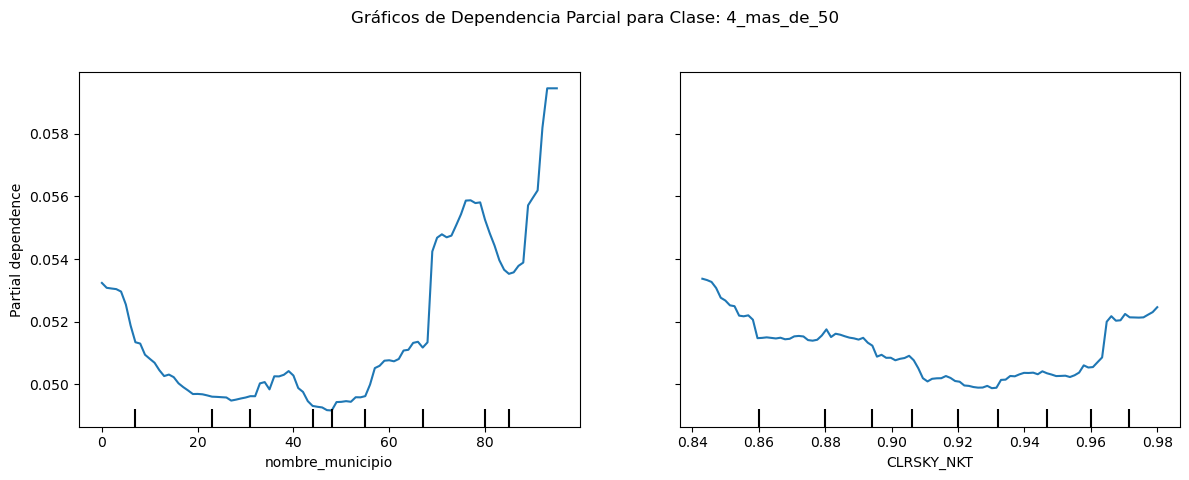

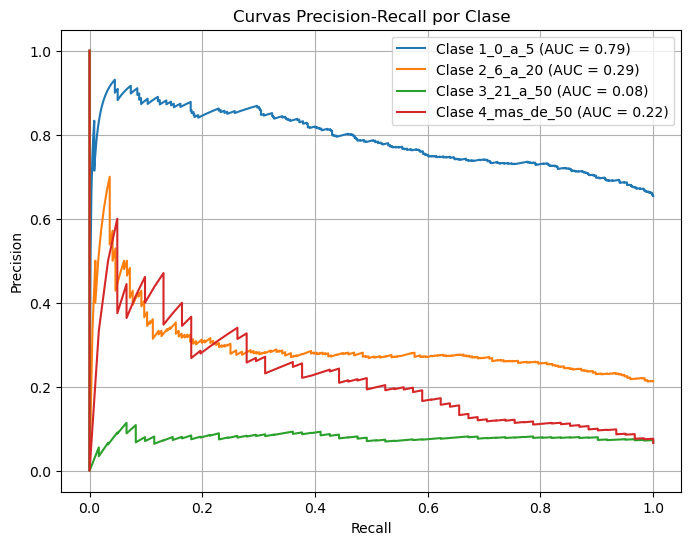

Exception ignored in: <function ResourceTracker.__del__ at 0x76d474b89760>
Traceback (most recent call last):
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7814aaf8d760>
Traceback (most recent call last):
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc
from sklearn.inspection import PartialDependenceDisplay

def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_macro'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Entrenamiento")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validación")
    plt.title("Curvas de Aprendizaje (F1-Macro)")
    plt.xlabel("Tamaño del Dataset de Entrenamiento")
    plt.ylabel("Score F1-Macro")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

def plot_normalized_cm(clf, X_val, y_val):
    y_pred = clf.predict(X_val)
    cm = confusion_matrix(y_val, y_pred, labels=clf.classes_)
    # Normalizar por fila (valores reales)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='RdYlGn', 
                xticklabels=clf.classes_, yticklabels=clf.classes_)
    plt.title("Matriz de Confusión Normalizada\n(Recall por clase en la diagonal)")
    plt.ylabel('Clase Real')
    plt.xlabel('Predicción del Modelo')
    plt.show()

# ================================================================
# 3. GRÁFICOS DE DEPENDENCIA PARCIAL (PDP)
# ================================================================
def plot_pdp(clf, X_train, features_to_plot):
    # Nota: PDP en multicapa muestra una curva por clase.
    # Graficaremos el impacto en la Clase 4 (incendios grandes)
    fig, ax = plt.subplots(figsize=(12, 5))
    PartialDependenceDisplay.from_estimator(
        clf, X_train, features_to_plot, 
        target='4_mas_de_50', # Enfocarnos en la clase crítica
        ax=ax
    )
    plt.suptitle("Gráficos de Dependencia Parcial para Clase: 4_mas_de_50")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_multiclass_precision_recall(clf, X_val, y_val):
    y_score = clf.predict_proba(X_val)
    plt.figure(figsize=(8, 6))
    
    for i, class_label in enumerate(clf.classes_):
        # Convertir a binario para la clase actual
        y_true_binary = (y_val == class_label).astype(int)
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score[:, i])
        pr_auc = auc(recall, precision)
        
        plt.plot(recall, precision, label=f'Clase {class_label} (AUC = {pr_auc:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall por Clase')
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()


# 1. Curva de aprendizaje
plot_learning_curve(clf, X_train, y_train)

# 2. Matriz Normalizada
plot_normalized_cm(clf, X_val, y_val)

# 3. PDP (Comparamos municipio vs una variable climática clave)
# Ajusta 'nombre_municipio' y la variable climática según tus nombres exactos de columnas
plot_pdp(clf, X_train, ['nombre_municipio', 'CLRSKY_NKT']) 

# 4. Precision-Recall
plot_multiclass_precision_recall(clf, X_val, y_val)

# Experimento 2

In [ ]:
import sys, os, duckdb
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

# ==============================================================================
# 0. VARIABLES DESCARTADAS (El filtro de entrada)
# ==============================================================================
VARS_DESCARTADAS = (
    'CLOUD_BT', 'CLOUD_BT_MAX', 'CLOUD_BT_MIN',
    'CLOUD_TT', 'CLOUD_TT_MAX', 'CLOUD_TT_MIN',
    'GWM_HEIGHT', 'GWM_HEIGHT_ANOMALY',
    'IMERG_PRECLIQUID_PROB', 'IMERG_PRECTOT', 'IMERG_PRECTOT_COUNT',
    'LWLAND', 'ORIGINAL_ALLSKY_SFC_LW_DWN', 'ORIGINAL_ALLSKY_SFC_SW_DWN',
    'ORIGINAL_CLRSKY_SFC_LW_DWN', 'ORIGINAL_CLRSKY_SFC_SW_DWN',
    'PRMC', 'PRMC_PRCNTL', 'RZMC', 'RZMC_PRCNTL',
    'SFMC', 'SWLAND', 'SZA'
)
vars_excluidas_sql = ", ".join([f"'{v}'" for v in VARS_DESCARTADAS])

# ==============================================================================
# 1. CARGA Y CLASIFICACIÓN INTELIGENTE (Solo variables válidas)
# ==============================================================================
# Filtramos el diccionario desde el inicio
df_diccionario = con.execute(f"""
    SELECT id_variable, fuente, nombre_completo 
    FROM working.diccionario 
    WHERE id_variable NOT IN ({vars_excluidas_sql})
""").df()

pivot_statements = []

for _, row in df_diccionario.iterrows():
    vid = row['id_variable']
    fuente = str(row['fuente']).lower()
    nombre = str(row['nombre_completo']).lower()
    
    base_case = f"CASE WHEN id_variable = '{vid}' THEN resultado_numerico END"
    
    if 'google' in fuente:
        pivot_statements.append(f"MAX({base_case}) AS \"{vid}\"")
    elif any(k in nombre for k in ['precipitation', 'precip', 'snow', 'rain']):
        pivot_statements.append(f"SUM({base_case}) AS \"{vid}_SUM\"")
    elif any(k in nombre for k in ['humidity', 'wetness', 'moisture']):
        pivot_statements.append(f"MIN({base_case}) AS \"{vid}_MIN\"")
    elif any(k in nombre for k in ['wind', 'speed']):
        pivot_statements.append(f"MAX({base_case}) AS \"{vid}_MAX\"")
        pivot_statements.append(f"STDDEV({base_case}) AS \"{vid}_STD\"")
    elif any(k in nombre for k in ['temperature', 'irradiance', 'insolation', 'solar', 'thermal', 'albedo', 'par', 'cdd']):
        pivot_statements.append(f"MAX({base_case}) AS \"{vid}_MAX\"")
    else:
        pivot_statements.append(f"MEDIAN({base_case}) AS \"{vid}_MEDIAN\"")

pivot_cols = ",\n    ".join(pivot_statements)

# ==============================================================================
# 2. EXTRACCIÓN CON DUCKDB (Filtrando variables descartadas para optimizar RAM)
# ==============================================================================
df = con.execute(f"""
    WITH clima_pivot AS (
        SELECT
            id_clave_inc,
            {pivot_cols}
        FROM working.climatologia
        WHERE id_variable NOT IN ({vars_excluidas_sql})
        GROUP BY id_clave_inc
    ),
    demo_total AS (
        SELECT
            id_cvegeo,
            anio,
            SUM(pob_total) AS pob_total
        FROM working.demografia
        GROUP BY id_cvegeo, anio
    )
    SELECT
        i.id_clave_inc,
        i.latitud,
        i.longitud,
        i.anio,
        EXTRACT(MONTH FROM i.fecha_inicio)::INTEGER AS mes,
        EXTRACT(DOW   FROM i.fecha_inicio)::INTEGER AS dia_semana,
        i.tipo_de_incendio,
        v.tipo_de_vegetacion,
        v.regimen_del_fuego,
        o.hora_deteccion,
        dem.pob_total,
        d.tamanio,
        cp.*
    FROM working.incendios i
    LEFT JOIN working.vegetacion   v   ON i.id_vegetacion = v.id_vegetacion
    LEFT JOIN working.municipios   m   ON i.id_cvegeo     = m.id_cvegeo
    LEFT JOIN working.operaciones  o   ON i.id_clave_inc  = o.id_clave_inc
    LEFT JOIN working.danos        d   ON i.id_clave_inc  = d.id_clave_inc
    LEFT JOIN demo_total           dem ON i.id_cvegeo     = dem.id_cvegeo
                                      AND i.anio          = dem.anio
    LEFT JOIN clima_pivot          cp  ON i.id_clave_inc  = cp.id_clave_inc
""").df()

con.close()

# ==============================================================================
# 3. LIMPIEZA INICIAL
# ==============================================================================
df = df.loc[:, ~df.columns.duplicated()]

df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')
df['hora_deteccion_min'] = (df['hora_deteccion'].dt.hour * 60 + df['hora_deteccion'].dt.minute)
df = df.drop(columns=['hora_deteccion'])

print(f"Dimensiones tras extracción: {df.shape}")

# ==============================================================================
# 4. LIMPIEZA QUIRÚRGICA, UNIFICACIÓN Y NULOS
# ==============================================================================
# Eliminar filas sin coordenadas
df_clean = df.dropna(subset=['latitud', 'longitud']).copy()

# Mapeo del Target
mapeo_clases = {
    '0 a 5 hectareas':       '1_0_a_5',
    '6 a 10 hectareas':      '2_6_a_20',
    '11 a 20 hectareas':     '2_6_a_20',
    '21 a 50 hectareas':     '3_21_a_50',
    '51 a 100 hectareas':    '4_mas_de_50',
    'mayor a 100 hectareas': '4_mas_de_50'
}
df_clean['tamanio_modelo'] = df_clean['tamanio'].map(mapeo_clases)

# Eliminar columnas 100% nulas (Fantasmas generadas por variables sin datos)
df_clean = df_clean.dropna(axis=1, how='all')

# Imputar nulos restantes (Suelos antiguos, NDMI) con la mediana
cols_numericas = df_clean.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns
df_clean[cols_numericas] = df_clean[cols_numericas].fillna(df_clean[cols_numericas].median())

# Seguridad contra nulos persistentes
df_clean[cols_numericas] = df_clean[cols_numericas].fillna(0)

print(f"Dimensiones finales (listas para el modelo): {df_clean.shape}")
print(f"Total de valores nulos: {df_clean.isnull().sum().sum()}")
print("\n--- Distribución Final del Target ---")
print(df_clean['tamanio_modelo'].value_counts(dropna=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dimensiones tras extracción: (12703, 157)
Dimensiones finales (listas para el modelo): (12529, 157)
Total de valores nulos: 0

--- Distribución Final del Target ---
tamanio_modelo
1_0_a_5        9536
2_6_a_20       2008
3_21_a_50       543
4_mas_de_50     442
Name: count, dtype: int64


/tmp/ipykernel_6793/3314694513.py:112: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')


/tmp/ipykernel_6793/2491589294.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tamanio_modelo', y=var_calor, data=df_clean,
/tmp/ipykernel_6793/2491589294.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tamanio_modelo', y=var_humedad, data=df_clean,
/tmp/ipykernel_6793/2491589294.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tamanio_modelo', y=var_viento, data=df_clean,


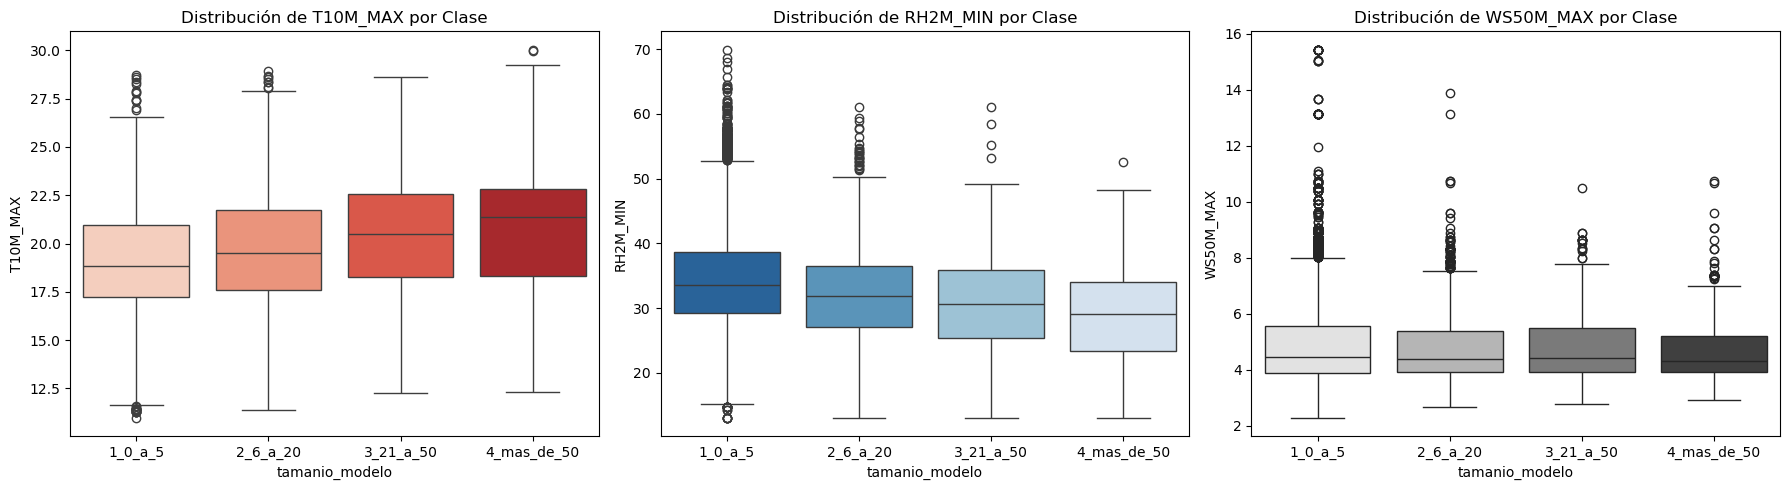

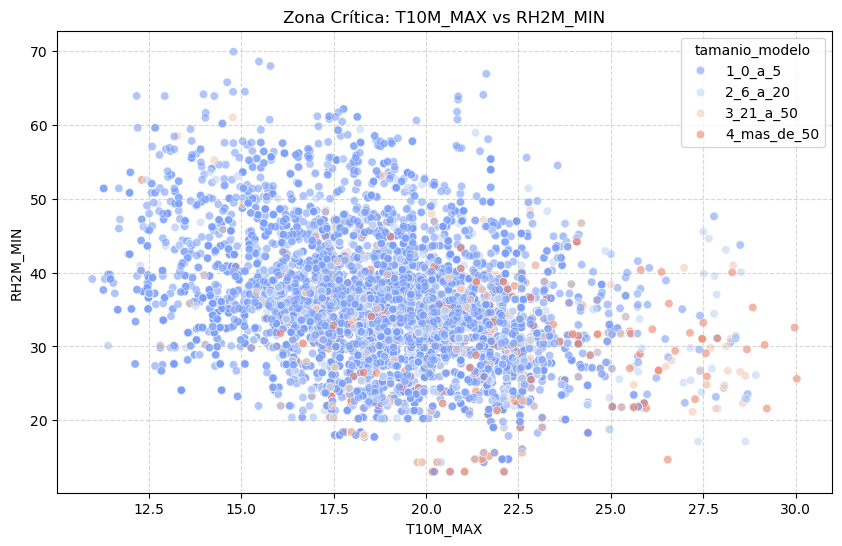

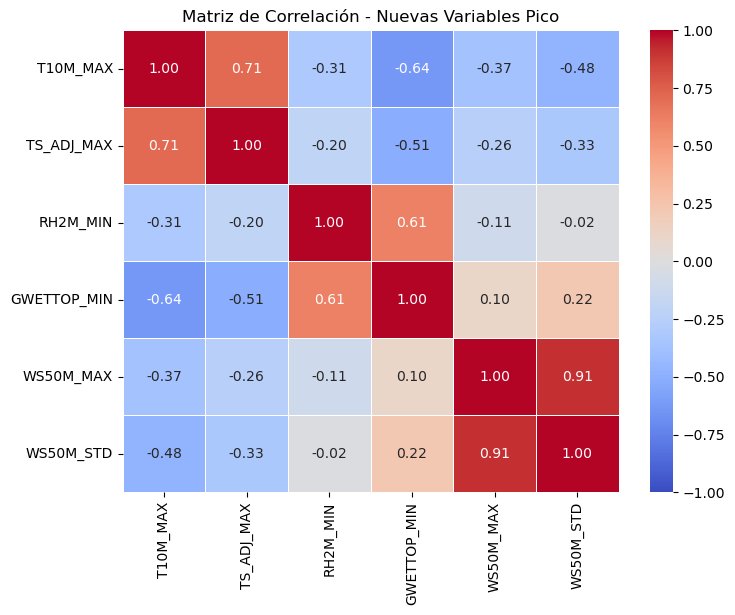

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# 1. VISUALIZACIÓN DE SEPARACIÓN DE CLASES (Boxplots y Scatter)
# ==============================================================================
# Nota: Ajusta los nombres de las columnas si en tu DF se llaman ligeramente distinto.
# Usaremos variables representativas que sabemos que salieron del diccionario.

# Elegimos 3 variables críticas de los nuevos grupos
var_calor = 'T10M_MAX'    # El pico de temperatura
var_humedad = 'RH2M_MIN'  # La caída crítica de humedad
var_viento = 'WS50M_MAX'  # Las ráfagas máximas

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1A. Boxplots: ¿Los incendios Clase 4 tienen picos más altos?
sns.boxplot(x='tamanio_modelo', y=var_calor, data=df_clean, 
            order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'], ax=axes[0], palette='Reds')
axes[0].set_title(f'Distribución de {var_calor} por Clase')

sns.boxplot(x='tamanio_modelo', y=var_humedad, data=df_clean, 
            order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'], ax=axes[1], palette='Blues_r')
axes[1].set_title(f'Distribución de {var_humedad} por Clase')

sns.boxplot(x='tamanio_modelo', y=var_viento, data=df_clean, 
            order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'], ax=axes[2], palette='Greys')
axes[2].set_title(f'Distribución de {var_viento} por Clase')

plt.tight_layout()
plt.show()

# 1B. Scatterplot 2D: Buscando la "Zona de Peligro"
plt.figure(figsize=(10, 6))
sns.scatterplot(x=var_calor, y=var_humedad, hue='tamanio_modelo', 
                hue_order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'],
                data=df_clean, alpha=0.6, palette='coolwarm')
plt.title(f'Zona Crítica: {var_calor} vs {var_humedad}')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================================================================
# 2. VERIFICACIÓN DE MULTICOLINEALIDAD (Matriz de Correlación)
# ==============================================================================
# Evaluar si las métricas derivadas de una misma fuente (o fuentes similares) 
# están diciendo exactamente lo mismo (correlación > 0.90)

# Seleccionamos un grupo de variables nuevas para inspeccionar
cols_a_revisar = [
    'T10M_MAX', 'TS_ADJ_MAX', # Dos medidas de calor
    'RH2M_MIN', 'GWETTOP_MIN', # Dos medidas de sequedad
    'WS50M_MAX', 'WS50M_STD'  # Viento: Ráfaga vs Inestabilidad
]

# Filtrar solo las que realmente existan en el DataFrame para evitar errores
cols_existentes = [c for c in cols_a_revisar if c in df_clean.columns]

plt.figure(figsize=(8, 6))
corr_matrix = df_clean[cols_existentes].corr()

# Mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación - Nuevas Variables Pico')
plt.show()

Dimensiones X_train : (10023, 153)
Dimensiones X_val   : (2506, 153)

Encoding listo. ¡Dataset 100% numérico preparado para el modelo!

Entrenando Random Forest con 'Freno de Mano'...
Modelo regularizado entrenado exitosamente.

--- Reporte de Clasificación (Validación) ---
              precision    recall  f1-score   support

     1_0_a_5       0.86      0.74      0.80      1907
    2_6_a_20       0.26      0.30      0.28       402
   3_21_a_50       0.10      0.17      0.12       109
 4_mas_de_50       0.13      0.30      0.18        88

    accuracy                           0.63      2506
   macro avg       0.34      0.38      0.34      2506
weighted avg       0.71      0.63      0.66      2506



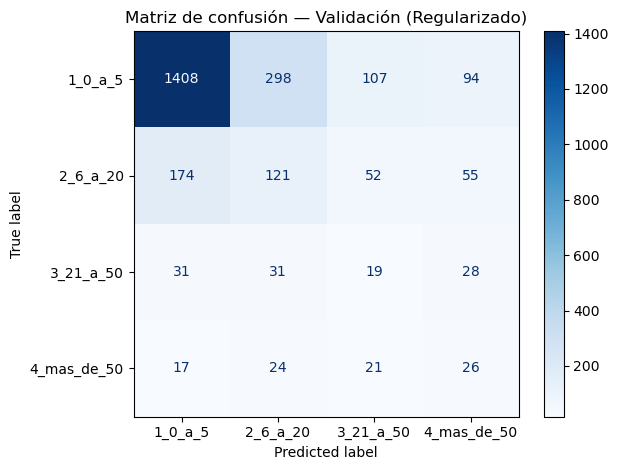

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ================================================================
# 1. DEFINICIÓN DE FEATURES (X) Y TARGET (y)
# ================================================================
TARGET_COL = 'tamanio_modelo'

# Columnas basura/target que no deben entrar al modelo
cols_a_excluir = ['id_clave_inc', 'tamanio', TARGET_COL]
if 'id_clave_inc_1' in df_clean.columns: # Por si se duplicó en el JOIN
    cols_a_excluir.append('id_clave_inc_1')

# Le pasamos TODO el arsenal climático al modelo (sin filtro de Pearson)
X = df_clean.drop(columns=cols_a_excluir)
y = df_clean[TARGET_COL]

# ================================================================
# 2. SPLIT DE DATOS (Train 80% / Val 20%)
# ================================================================
# Usamos stratify=y para asegurar que las clases raras queden bien repartidas
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Dimensiones X_train : {X_train.shape}")
print(f"Dimensiones X_val   : {X_val.shape}")

# ================================================================
# 3. ENCODING DE CATEGÓRICAS
# ================================================================
# Solo codificamos las variables físicas y operativas (sin municipio)
cols_categoricas = ['tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego']

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cols_categoricas] = enc.fit_transform(X_train[cols_categoricas])
X_val[cols_categoricas]   = enc.transform(X_val[cols_categoricas])

print("\nEncoding listo. ¡Dataset 100% numérico preparado para el modelo!")

# ================================================================
# 4. ENTRENAMIENTO — Random Forest (REGULARIZADO)
# ================================================================
print("\nEntrenando Random Forest con 'Freno de Mano'...")

clf_regularizado = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = 12,            # FRENO 1: Profundidad limitada
    min_samples_leaf= 15,            # FRENO 2: Hojas robustas
    max_features    = 'sqrt',        # FRENO 3: Decorrelación
    class_weight    = 'balanced',    # PROTECCIÓN: Castigo a fallos en clases minoritarias
    random_state    = 42,
    n_jobs          = -1
)

clf_regularizado.fit(X_train, y_train)
print("Modelo regularizado entrenado exitosamente.")

# ================================================================
# 5. EVALUACIÓN — Validación
# ================================================================
y_pred_val = clf_regularizado.predict(X_val)

print("\n--- Reporte de Clasificación (Validación) ---")
print(classification_report(y_val, y_pred_val))

# Matriz de confusión
cm  = confusion_matrix(y_val, y_pred_val, labels=clf_regularizado.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_regularizado.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — Validación (Regularizado)')
plt.tight_layout()
plt.show()

--- TOP 25 VARIABLES MÁS IMPORTANTES ---
            Variable  Importancia
                anio     0.031596
            longitud     0.020907
             latitud     0.015651
          TSOIL6_MAX     0.014896
           pob_total     0.013845
          TSOIL5_MAX     0.013379
   regimen_del_fuego     0.013267
      EVPTRNS_MEDIAN     0.012051
                NDWI     0.011941
         T2M_MAX_MAX     0.011507
     CLOUD_OD_MEDIAN     0.011031
                NDMI     0.010956
              PW_SUM     0.010700
          TSOIL4_MAX     0.010681
            RH2M_MIN     0.010466
          TSOIL3_MAX     0.010290
            WD2M_STD     0.009977
                NDVI     0.009678
ALLSKY_SFC_SW_UP_MAX     0.009466
           WD10M_STD     0.009296
           WD50M_STD     0.009293
             TQV_SUM     0.008962
           TROPT_MAX     0.008932
       EVLAND_MEDIAN     0.008554
           PS_MEDIAN     0.008448


/tmp/ipykernel_6793/1667849650.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


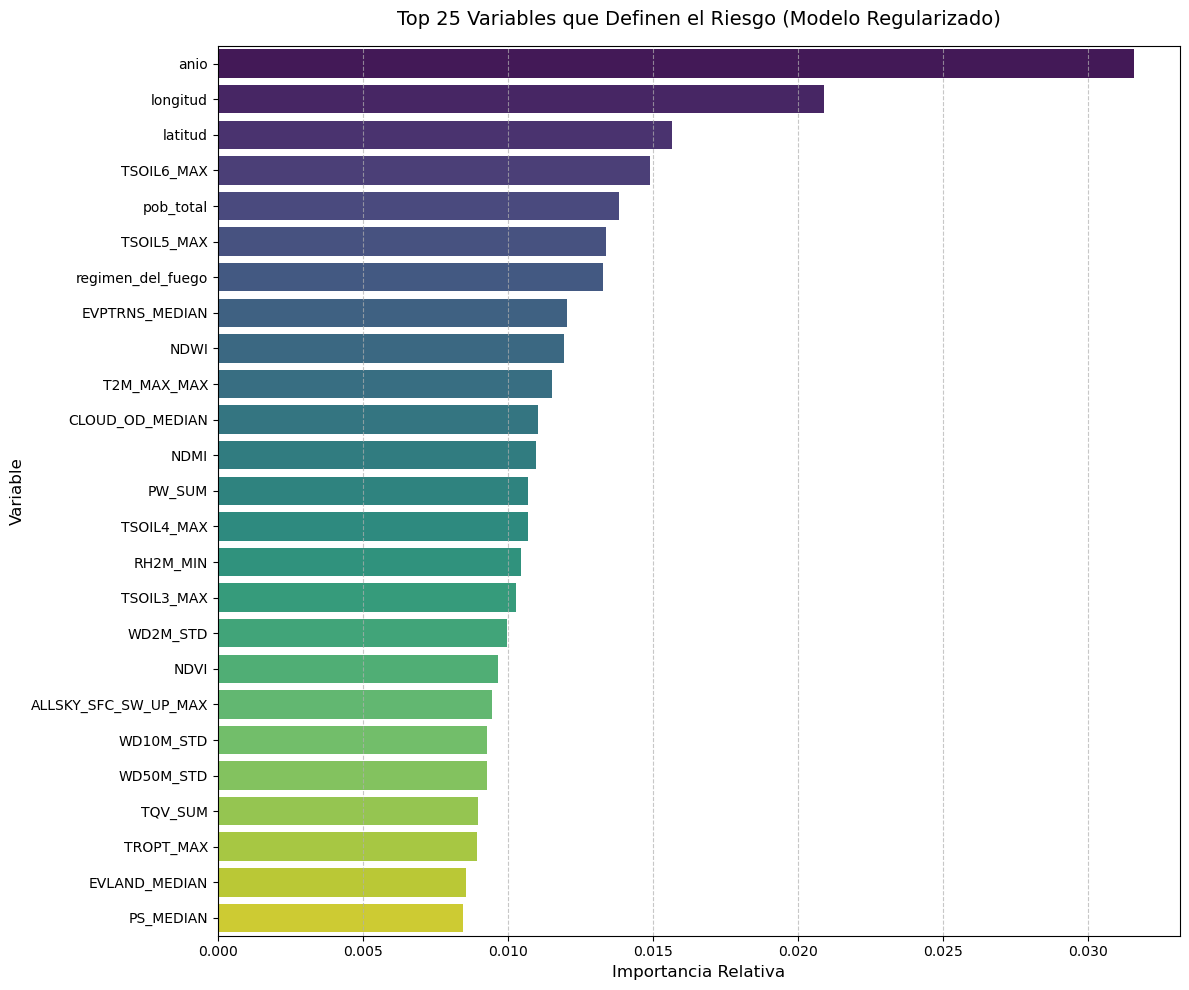

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# 6. EXTRACCIÓN DEL RANKING DE IMPORTANCIA (FEATURE IMPORTANCE)
# ================================================================

# 1. Extraer las importancias del modelo regularizado
importancias = clf_regularizado.feature_importances_
nombres_features = X_train.columns

# 2. Crear un DataFrame y ordenar de mayor a menor
df_importancias = pd.DataFrame({
    'Variable': nombres_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 3. Mostrar el Top 25 numéricamente en consola
print("--- TOP 25 VARIABLES MÁS IMPORTANTES ---")
print(df_importancias.head(25).to_string(index=False))

# 4. Graficar el Top 25
plt.figure(figsize=(12, 10))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importancias.head(25), 
    palette='viridis'
)
plt.title('Top 25 Variables que Definen el Riesgo (Modelo Regularizado)', fontsize=14, pad=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1/5 Calculando Curvas de Aprendizaje...


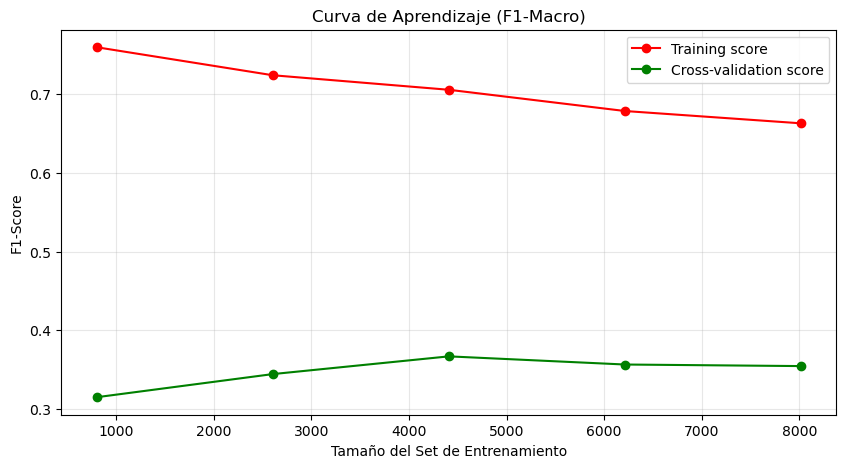

2/5 Generando Matriz de Confusión Normalizada...


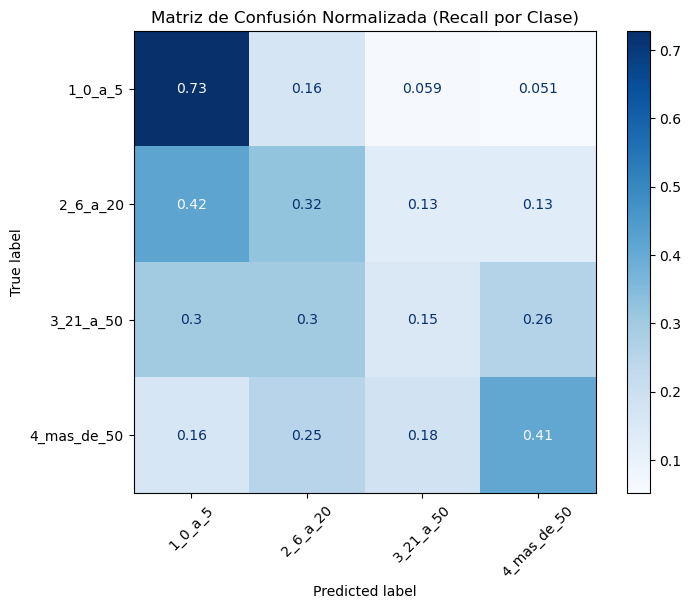

3/5 Analizando Importancia de Variables...


/tmp/ipykernel_6793/3083198460.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importancias.head(20), palette='viridis')


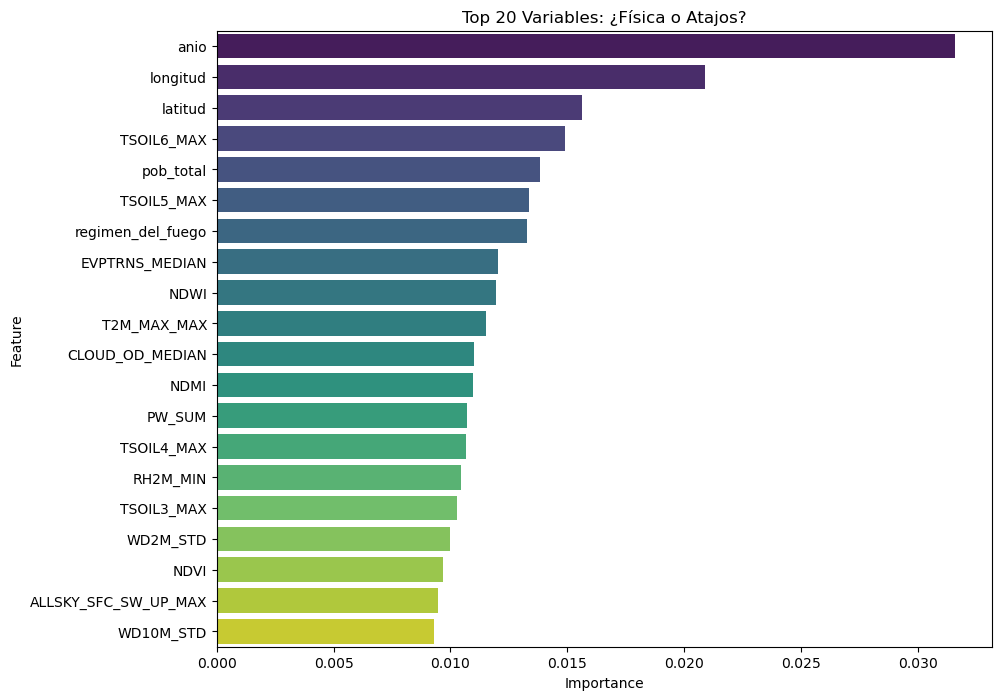

4/5 Calculando Gráficos de Dependencia Parcial (PDP)...


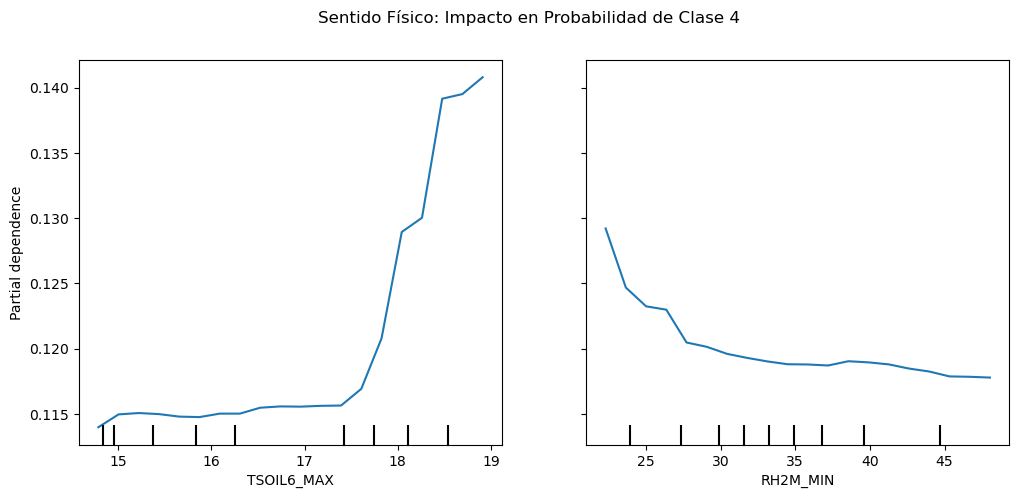

5/5 Ejecutando Autopsia de Falsos Negativos...

--- REPORTE DE AUTOPSIA ---
Total de incendios Clase 4 ignorados: 7

Promedio en Set de Prueba Completo:
TSOIL6_MAX        16.634645
RH2M_MIN          33.552067
anio            2019.881085
pob_total     156792.770950
dtype: float64

Promedio en los Falsos Negativos (Los que el modelo no vió):
TSOIL6_MAX       16.652857
RH2M_MIN         33.017143
anio           2020.714286
pob_total     54401.714286
dtype: float64


Exception ignored in: <function ResourceTracker.__del__ at 0x74fb3c98d760>
Traceback (most recent call last):
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7b445ef85760>
Traceback (most recent call last):
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.inspection import PartialDependenceDisplay

# ==============================================================================
# 1. CURVAS DE APRENDIZAJE (Sesgo vs. Varianza)
# ==============================================================================
print("1/5 Calculando Curvas de Aprendizaje...")
train_sizes, train_scores, test_scores = learning_curve(
    clf_regularizado, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_macro'
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="r", label="Training score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="g", label="Cross-validation score")
plt.title("Curva de Aprendizaje (F1-Macro)")
plt.xlabel("Tamaño del Set de Entrenamiento")
plt.ylabel("F1-Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

# ==============================================================================
# 2. MATRIZ DE CONFUSIÓN NORMALIZADA (Trampa de la Clase Mayoritaria)
# ==============================================================================
print("2/5 Generando Matriz de Confusión Normalizada...")
cm = confusion_matrix(y_test, y_pred_test, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_regularizado.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusión Normalizada (Recall por Clase)")
plt.show()

# ==============================================================================
# 3. IMPORTANCIA DE VARIABLES (Física vs. Ruido)
# ==============================================================================
print("3/5 Analizando Importancia de Variables...")
importancias = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': clf_regularizado.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importancias.head(20), palette='viridis')
plt.title("Top 20 Variables: ¿Física o Atajos?")
plt.show()

# ==============================================================================
# 4. GRÁFICOS DE DEPENDENCIA PARCIAL (PDP - Sentido Físico)
# ==============================================================================
print("4/5 Calculando Gráficos de Dependencia Parcial (PDP)...")
# Analizamos la Clase 4 (incendios grandes)
features_to_plot = ['TSOIL6_MAX', 'RH2M_MIN'] 

fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    clf_regularizado, X_train, features_to_plot, 
    target='4_mas_de_50', ax=ax, grid_resolution=20
)
plt.suptitle("Sentido Físico: Impacto en Probabilidad de Clase 4")
plt.show()

# ==============================================================================
# 5. AUTOPSIA DE FALSOS NEGATIVOS (Análisis Cualitativo)
# ==============================================================================
print("5/5 Ejecutando Autopsia de Falsos Negativos...")
# Dataset de comparación
df_test_analysis = X_test.copy()
df_test_analysis['Real'] = y_test.values
df_test_analysis['Pred'] = y_pred_test

# Casos críticos: Eran Clase 4 pero el modelo dijo Clase 1
falsos_negativos = df_test_analysis[
    (df_test_analysis['Real'] == '4_mas_de_50') & 
    (df_test_analysis['Pred'] == '1_0_a_5')
]

print(f"\n--- REPORTE DE AUTOPSIA ---")
print(f"Total de incendios Clase 4 ignorados: {len(falsos_negativos)}")

# Comparativa de variables críticas
variables_criticas = ['TSOIL6_MAX', 'RH2M_MIN', 'anio', 'pob_total']
print("\nPromedio en Set de Prueba Completo:")
print(X_test[variables_criticas].mean())

print("\nPromedio en los Falsos Negativos (Los que el modelo no vió):")
if not falsos_negativos.empty:
    print(falsos_negativos[variables_criticas].mean())
else:
    print("¡No hay falsos negativos críticos para analizar!")

In [ ]:
# ¿Ha cambiado la proporción de incendios grandes con el tiempo?
print(df_clean.groupby('anio')['tamanio_modelo'].value_counts(normalize=True).unstack())

tamanio_modelo   1_0_a_5  2_6_a_20  3_21_a_50  4_mas_de_50
anio                                                      
2015            0.908333  0.085417   0.006250          NaN
2016            0.883820  0.102637   0.012117     0.001426
2017            0.843273  0.121359   0.020111     0.015257
2018            0.840146  0.116058   0.032117     0.011679
2019            0.816825  0.137042   0.029172     0.016961
2020            0.758748  0.183241   0.032228     0.025783
2021            0.758389  0.165772   0.041611     0.034228
2022            0.697395  0.200401   0.059118     0.043086
2023            0.654348  0.213043   0.066304     0.066304
2024            0.561567  0.221082   0.100746     0.116604
2025            0.547859  0.261965   0.103275     0.086902
